In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib as mpl
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [42]:
# ----- DEFINE FUNCTIONS -----

def testNormal(input, alpha=0.05):
    if len(input) >= 20:
        #This function is based on D’Agostino and Pearson’s test that combines skew and kurtosis to produce an omnibus test of normality
        results = scipy.stats.normaltest(input) 
        p_values = results.pvalue
        normal_method = "D'Agostino-Pearson test (combined kurtosis + skewness)"
        if p_value > alpha: isnormal = True
        elif p_value <= alpha: isnormal = False
    else: 
        #For n<20, we have to rely on a Monte Carlo approach to test skew and kurtosis (kurtosistest is only valid n>=20) 
        rvs = lambda size: scipy.stats.norm.rvs(size=size, random_state=np.random.default_rng())
        skew_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.skew, vectorized=True)
        kurtosis_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.kurtosis, vectorized=True)
        p_values = [skew_results.pvalue, kurtosis_results.pvalue]
        normal_method = "Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)"
        # data is only treated as normal if it has both normal skew and kurtosis
        if p_values[0] > 0.05 and p_values[1] > alpha: isnormal = True
        else: isnormal = False
    return isnormal, p_values, normal_method

def decide_pval_text(pval,palpha):

    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'

    return ptxt
    
def add_pair_to_plot(df,stat_base,ax,pcol,scol,startx,dotdist,errdist,psdist,ptxt):

    # -- PARTNER --
    statkey = f'{stat_base}_partner'
    tcol = pcol

    max1 = np.max(df[statkey])
    
    # plot partner dots
    ax.plot(np.zeros(df.shape[0])+startx+dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor=tcol,zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot partner bar and error
    tmean = np.mean(df[statkey])
    se = scipy.stats.sem(df[statkey])
    bplot = ax.bar(startx,tmean,edgecolor=tcol,width=boxwidth,zorder=0)
    ax.errorbar(startx-errdist,tmean,yerr=se,ecolor=tcol,elinewidth=boxlw,zorder=2)
    ax.bar(startx,tmean,edgecolor=tcol,facecolor='None',width=boxwidth,linewidth=boxlw,zorder=1)
    
    for patch in bplot:
        patch.set_facecolor(tcol)
        patch.set_alpha(boxalpha)
    
    # -- STRANGER --    
    statkey = f'{stat_base}_stranger'
    tcol = scol

    max2 = np.max(df[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(df.shape[0])+startx+psdist-dotdist, df[statkey], 'o', markerfacecolor=tcol,markeredgecolor=tcol,zorder=4, ms=5, mew=1, alpha=1)
    
    # plot stranger bar and error
    tmean = np.mean(df[statkey])
    se = scipy.stats.sem(df[statkey])
    bplot = ax.bar(startx+psdist,tmean,edgecolor=tcol,width=boxwidth,zorder=0)
    ax.errorbar(startx+psdist+errdist,tmean,yerr=se,ecolor=tcol,elinewidth=boxlw,zorder=2)
    ax.bar(startx+psdist,tmean,edgecolor=tcol,facecolor='None',width=boxwidth,zorder=1,linewidth=boxlw)  
    
    for patch in bplot:
        patch.set_facecolor(tcol)
        patch.set_alpha(boxalpha)
    
    # plot pair lines
    for idx in df.index: ax.plot([startx+dotdist,startx+psdist-dotdist], df.loc[idx,['fraction_partner','fraction_stranger']], 
                                 color = 'k', linewidth = 0.5, linestyle = '-', zorder=3)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = np.max([max1,max2]) + ppad*np.max([max1,max2]), ppad
    px1 = startx
    px2 = startx+psdist
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color='k',size=6)

In [79]:
# ----- SET GLOBAL PARAMETERS -----

# matplotlib plotting defaults
mpl.rcParams['lines.linewidth'] = 2

mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 6

mpl.rcParams['xtick.labelsize'] = 5
mpl.rcParams['ytick.labelsize'] = 5

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

plt.rcParams['svg.fonttype'] = 'none'

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    [0.34901962, 0.35686275, 0.49019608],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# stats and plotting params
csz = 0 # !!!
ewd = 1 # !!!
dotadj = -0.5 # offset for dots from boxplot position
ebaradj = 0.15 # !!!
barline = 0.5 # !!!

# outlier flier marker properties
fmrkr = 'x'
fmrkrsz = 4

figsz = (2,2) # total size of figure
boxalpha = 0.5 # transparency for boxplot face color

boxlw = 1 # boxplot linewidth
medlw = 1.5 # median linewidth
bwidth = 0.25 # box width
caps = False # don't put caps on the error bars

ppad = 0.085 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket
pcol = 'k' # color for pvalue bracket
palpha = 0.05 # threshold for significance

ci = 0.95 # normal data box plot confidence interval

# parameters for naive choice index plots
xt = 0.3 # x adjustment for jitter
jitter = 0.2 # jitter value
jitpad = jitter*4 # how much x axis padding to have around the jitter value

# data management
na_column = "Unknown_sec"

In [3]:
# ----- LOAD DATA -----
data = pd.read_csv(os.path.join('..','all_annotations.csv'))
data = data.drop(labels=['Unnamed: 0','id'],axis=1)
data.head()

# ----- FILTER TO PPT DATA -----
allppt = data[data['assay']=='PPT'].copy().reset_index()
np.unique(allppt.behavior)

# ----- CALCULATE PARTNER/STRANGER CHAMBER TIMES -----
assaydur = 3*60*60 # length of PPT in seconds

# sum time doing each behavior
behavsums = allppt.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()

# define partner and stranger oriented behaviors to combine for total chamber time
partnerBehavs = ['Huddle Partner','Interact Partner','Partner']
strangerBehavs = ['Huddle Stranger','Interact Stranger','Stranger']

# combine partner oriented behaviors into one partner time total
partnercomponents = behavsums[behavsums['behavior'].isin(partnerBehavs)].copy().reset_index(drop=True)
partnersums = partnercomponents.groupby(by=['pair_tag','GT','sex',]).duration.sum().reset_index()

# combine stranger oriented behaviors into one stranger time total
strangercomponents = behavsums[behavsums['behavior'].isin(strangerBehavs)].copy().reset_index(drop=True)
strangersums = strangercomponents.groupby(by=['pair_tag','GT','sex',]).duration.sum().reset_index()

# combine partner and stranger data into one dataframe
chamber = partnersums.rename(columns={"duration": "partner"})
chamber['stranger'] = strangersums.duration

# calculate fractions
chamber['fraction_partner'] = chamber['partner']/assaydur
chamber['fraction_stranger'] = chamber['stranger']/assaydur

chamber

,pair_tag,GT,sex,partner,stranger,fraction_partner,fraction_stranger
0,Pair1,Het,F,4701.327,3399.127,0.435308,0.314734
1,Pair15,Het,F,8327.292,1711.989,0.771046,0.158518
2,Pair16,WT,F,9910.680,366.035,0.917656,0.033892
3,Pair17,Het,M,5088.112,4963.527,0.471121,0.459586
4,Pair18,WT,M,7715.188,1993.433,0.714369,0.184577
5,Pair19,WT,M,5275.856,4125.194,0.488505,0.381962
6,Pair2,WT,F,6050.815,4177.273,0.560261,0.386785
7,Pair21,Het,F,8705.082,1689.166,0.806026,0.156404
8,Pair22,Het,F,7520.919,1568.557,0.696381,0.145237
9,Pair23,Het,F,7943.869,2503.420,0.735543,0.231798


In [116]:
savefigs=True

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           50                Method:                       REML    
No. Groups:                 25                Scale:                        0.0571  
Min. group size:            2                 Log-Likelihood:               -4.2362 
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.707    0.058 12.114 0.000  0.592  0.821
C(stim, Treatment('partner'))[T.stranger] -0.484    0.068 -7.160 0.000 -0.616 -0.351
C(GT

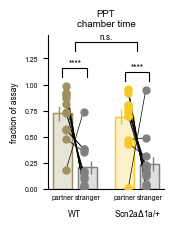

In [117]:
# ----- PLOT FEMALE CHAMBER TIME -----

sex = 'female'

fname = f'PPT_chamber_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = chamber[chamber['sex']==sexlet].copy().reset_index(drop=True)

# savefigs = False

scol = [0.5,0.5,0.5]
lbls = ['partner','stranger']*2
xlab = ''
ylab = 'fraction of assay'
stat = 'chamber time'
ttl = f'PPT\n{stat}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# get pvalues to plot
gtp = mdf.wald_test_terms().pvalues[2]
partnerp = mdf.wald_test_terms().pvalues[1]

# process pvalues into text
gtp_text = decide_pval_text(gtp,0.05)
partnerp_text = decide_pval_text(partnerp,0.05)

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
pcol = fcols[0]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
pcol = fcols[1]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,partnerp_text)

# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0,1.25])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           52                Method:                       REML    
No. Groups:                 26                Scale:                        0.0378  
Min. group size:            2                 Log-Likelihood:               5.8091  
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.616    0.045 13.676 0.000  0.528  0.704
C(stim, Treatment('partner'))[T.stranger] -0.316    0.054 -5.864 0.000 -0.422 -0.211
C(GT

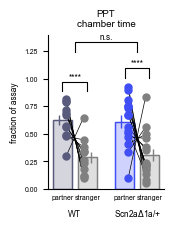

In [118]:
# ----- PLOT MALE CHAMBER TIME -----

sex = 'male'

fname = f'PPT_chamber_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = chamber[chamber['sex']==sexlet].copy().reset_index(drop=True)

# savefigs = False

scol = [0.5,0.5,0.5]
lbls = ['partner','stranger']*2
xlab = ''
ylab = 'fraction of assay'
stat = 'chamber time'
ttl = f'PPT\n{stat}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# get pvalues to plot
gtp = mdf.wald_test_terms().pvalues[2]
partnerp = mdf.wald_test_terms().pvalues[1]

# process pvalues into text
gtp_text = decide_pval_text(gtp,0.05)
partnerp_text = decide_pval_text(partnerp,0.05)

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
pcol = cols[0]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
pcol = cols[1]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,partnerp_text)

# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0,1.25])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

In [64]:
# ----- FILTER TO PPT DATA -----
# allppt = data[data['assay']=='PPT'].copy().reset_index()
# np.unique(allppt.behavior)

# ----- CALCULATE PARTNER/STRANGER CHAMBER TIMES -----
# assaydur = 3*60*60 # length of PPT in seconds

# sum time doing each behavior
behavsums = allppt.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()

# define partner and stranger oriented behaviors
phuddle = ['Huddle Partner']
shuddle = ['Huddle Stranger']

# narrow down to only huddles
phuddles = behavsums[behavsums['behavior'].isin(phuddle)].copy().reset_index(drop=True).rename(columns={"duration": "huddle_partner"})
shuddles = behavsums[behavsums['behavior'].isin(shuddle)].copy().reset_index(drop=True).rename(columns={"duration": "huddle_stranger"})

# combine
huddle=phuddles.merge(shuddles,on='pair_tag',how='outer').drop(labels=['GT_y','sex_y','behavior_y',
                                                                       'behavior_x'],axis=1).rename(columns={'GT_x': 'GT', 'sex_x': 'sex'}).fillna(0)

# calculate fractions
huddle['fraction_partner'] = huddle['huddle_partner']/assaydur
huddle['fraction_stranger'] = huddle['huddle_stranger']/assaydur

# calculate preference index
huddle['preference_index'] = (huddle['huddle_partner']-huddle['huddle_stranger'])/(huddle['huddle_partner']+huddle['huddle_stranger'])

# fix missing metadata
huddle.loc[17,'GT']='Het'
huddle.loc[17,'sex']='F'

huddle

,pair_tag,GT,sex,huddle_partner,huddle_stranger,fraction_partner,fraction_stranger,preference_index
0,Pair1,Het,F,2503.422,0.000,0.231798,0.000000,1.000000
1,Pair15,Het,F,6924.177,325.860,0.641127,0.030172,0.910108
2,Pair16,WT,F,8337.018,11.251,0.771946,0.001042,0.997305
3,Pair17,Het,M,3583.733,141.490,0.331827,0.013101,0.924037
4,Pair18,WT,M,3878.976,613.914,0.359164,0.056844,0.726718
5,Pair19,WT,M,1384.563,463.983,0.128200,0.042961,0.498002
6,Pair2,WT,F,5013.233,1755.192,0.464188,0.162518,0.481359
7,Pair21,Het,F,6814.198,150.324,0.630944,0.013919,0.956831
8,Pair22,Het,F,3887.041,36.732,0.359911,0.003401,0.981277
9,Pair23,Het,F,5739.463,42.741,0.531432,0.003958,0.985216


C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           50                Method:                       REML    
No. Groups:                 25                Scale:                        0.0308  
Min. group size:            2                 Log-Likelihood:               10.1963 
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.505    0.043 11.766 0.000  0.421  0.589
C(stim, Treatment('partner'))[T.stranger] -0.479    0.050 -9.650 0.000 -0.576 -0.382
C(GT

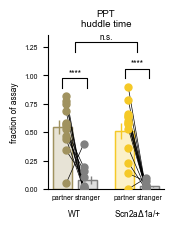

In [119]:
# ----- PLOT FEMALE HUDDLE TIME -----
sex = 'female'

fname = f'PPT_huddle_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

# savefigs = False

scol = [0.5,0.5,0.5]
lbls = ['partner','stranger']*2
xlab = ''
ylab = 'fraction of assay'
stat = 'huddle time'
ttl = f'PPT\n{stat}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# get pvalues to plot
gtp = mdf.wald_test_terms().pvalues[2]
partnerp = mdf.wald_test_terms().pvalues[1]

# process pvalues into text
gtp_text = decide_pval_text(gtp,0.05)
partnerp_text = decide_pval_text(partnerp,0.05)

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
pcol = cols[0]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
pcol = cols[1]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,partnerp_text)

# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0,1.25])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\nhogl\miniconda3\envs\mscn2a\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           fraction
No. Observations:           52                Method:                       REML    
No. Groups:                 26                Scale:                        0.0380  
Min. group size:            2                 Log-Likelihood:               4.1715  
Max. group size:            2                 Converged:                    No      
Mean group size:            2.0                                                     
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.412    0.047  8.763 0.000  0.320  0.504
C(stim, Treatment('partner'))[T.stranger] -0.321    0.054 -5.933 0.000 -0.427 -0.215
C(GT

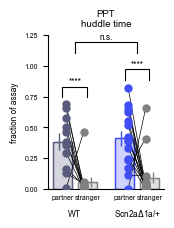

In [120]:
# ----- PLOT MALE HUDDLE TIME -----
sex = 'male'

fname = f'PPT_huddle_{sex}.svg'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

# savefigs = False

scol = [0.5,0.5,0.5]
lbls = ['partner','stranger']*2
xlab = ''
ylab = 'fraction of assay'
stat = 'huddle time'
ttl = f'PPT\n{stat}'
boxalpha = 0.25 # transparency for boxplot face color
boxwidth = 0.75

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# remodel tab
tabw = tab[['pair_tag','GT','fraction_partner','fraction_stranger']].copy()

tabl = pd.wide_to_long(
    tabw, stubnames="fraction", i=["pair_tag", "GT"], j="stim",sep='_',suffix=r"\w+",
).reset_index()

pair_num = tabl.pair_tag.transform(lambda x: int(x.strip('Pair')))
tabl['subject'] = pair_num

md = smf.mixedlm("fraction ~ C(stim,Treatment('partner')) + C(GT)", tabl, groups=tabl['subject'])
mdf = md.fit()
print(mdf.summary())

# get pvalues to plot
gtp = mdf.wald_test_terms().pvalues[2]
partnerp = mdf.wald_test_terms().pvalues[1]

# process pvalues into text
gtp_text = decide_pval_text(gtp,0.05)
partnerp_text = decide_pval_text(partnerp,0.05)

# make figure
fig, ax = plt.subplots(figsize=figsz)

stat_base = 'fraction'

# --- PLOT WT DATA ---
df = tabw[tabw['GT']=='WT'].copy().reset_index(drop=True) # configure data to WT
pcol = cols[0]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start,dotdist,errdist,psdist,partnerp_text)

# --- PLOT HET DATA ---
df = tabw[tabw['GT']=='Het'].copy().reset_index(drop=True) # configure data to Het
pcol = cols[1]
add_pair_to_plot(df,stat_base,ax,pcol,scol,start+psdist+gtdist,dotdist,errdist,psdist,partnerp_text)

# --- ADD STATS ANNOTATION ---
# plot stats test result
bottom, top = plt.ylim()  # return the current ylim
y, h = top + ppad*top, ppad
px1 = start+psdist/2
px2 = start+psdist+gtdist+psdist/2
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((px1+px2)*.5, y+h+0.1*h, gtp_text, ha='center', va='bottom', color='k',size=6)

# --- GENERAL PLOT STUFF ---
# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# adjust labeling parameters
ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls)
ax.set_yticks([0,0.25,0.5,0.75,1.0,1.25])
ax.tick_params(axis='x', which='both',length=0)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl)
fig.text(0.3, -0.025, 'WT', ha='center',size=6)
fig.text(0.725, -0.025, 'Scn2a$ \Delta $1a/+', ha='center',size=6)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

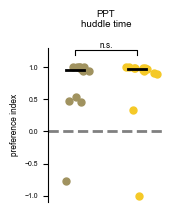

In [121]:
# ----- FEMALE PREFERENCE INDEX -----

sex = 'female'

fname = f'PPT_index_{sex}.svg'

figsz = (1.5,2) # total size of figure
jitter = 0.1 # jitter value
spacing = 0.7
ptxt='n.s.'
ylab = 'preference index'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

# jitter dots
tab['jitter'] = np.random.normal(loc=0, scale=jitter, size=tab.shape[0])

# make figure
fig, ax = plt.subplots(figsize=figsz)

# plot WT dots in WT color
ttab = tab[tab['GT']=='WT'].copy().reset_index(drop=True)
ax.plot(ttab['jitter']+0,ttab['preference_index'], 'o', markerfacecolor=cols[0], 
    markeredgecolor=cols[0],zorder=1, ms=5, mew=1)
ctline = np.median(ttab['preference_index'])
ax.plot([-jitter,jitter],[ctline,ctline],color='k',linewidth=2,zorder=2)

# plot het dots in het color
ttab = tab[tab['GT']=='Het'].copy().reset_index(drop=True)
ax.plot(ttab['jitter']+spacing,ttab['preference_index'], 'o', markerfacecolor=cols[1], 
    markeredgecolor=cols[1],zorder=1, ms=5, mew=1)
ctline = np.median(ttab['preference_index'])
ax.plot([-jitter+spacing,jitter+spacing],[ctline,ctline],color='k',linewidth=2,zorder=2)

# plot stats test result
y, h = 1 + ppad+0.1, ppad
px1 = 0
px2 = spacing
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((spacing)/2, y+h, ptxt, ha='center', va='bottom', color='k',size=6)

# plot line at 0
ax.plot([0-3*jitter,spacing+3*jitter],[0,0],'--',color=[0.5,0.5,0.5],zorder=-1)

# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_xlim(0-3*jitter,spacing+3*jitter)
ax.set_ylim(-1.1,1.3)

# labels and title
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl,pad=15)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')

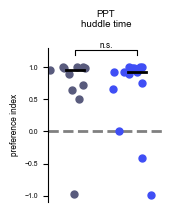

In [122]:
# ----- MALE PREFERENCE INDEX -----

sex = 'male'

fname = f'PPT_index_{sex}.svg'

figsz = (1.5,2) # total size of figure
jitter = 0.1 # jitter value
spacing = 0.7
ptxt='n.s.'
ylab = 'preference index'

if sex=='male':
    sexlet = 'M'
    cols = mcols
else:
    sexlet = 'F'
    cols = fcols

tab = huddle[huddle['sex']==sexlet].copy().reset_index(drop=True)

# jitter dots
tab['jitter'] = np.random.normal(loc=0, scale=jitter, size=tab.shape[0])

# make figure
fig, ax = plt.subplots(figsize=figsz)

# plot WT dots in WT color
ttab = tab[tab['GT']=='WT'].copy().reset_index(drop=True)
ax.plot(ttab['jitter']+0,ttab['preference_index'], 'o', markerfacecolor=cols[0], 
    markeredgecolor=cols[0],zorder=1, ms=5, mew=1)
ctline = np.median(ttab['preference_index'])
ax.plot([-jitter,jitter],[ctline,ctline],color='k',linewidth=2,zorder=2)

# plot het dots in het color
ttab = tab[tab['GT']=='Het'].copy().reset_index(drop=True)
ax.plot(ttab['jitter']+spacing,ttab['preference_index'], 'o', markerfacecolor=cols[1], 
    markeredgecolor=cols[1],zorder=1, ms=5, mew=1)
ctline = np.median(ttab['preference_index'])
ax.plot([-jitter+spacing,jitter+spacing],[ctline,ctline],color='k',linewidth=2,zorder=2)

# plot stats test result
y, h = 1 + ppad+0.1, ppad
px1 = 0
px2 = spacing
ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
plt.text((spacing)/2, y+h, ptxt, ha='center', va='bottom', color='k',size=6)

# plot line at 0
ax.plot([0-3*jitter,spacing+3*jitter],[0,0],'--',color=[0.5,0.5,0.5],zorder=-1)

# remove axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_xlim(0-3*jitter,spacing+3*jitter)
ax.set_ylim(-1.1,1.3)

# labels and title
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(ttl,pad=15)

# save
if savefigs:
    plt.savefig(fname,bbox_inches='tight')